<a href="https://colab.research.google.com/github/gaikwadritik741-sys/MDM-ML/blob/main/ML_10EE555.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [ ]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [ ]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)


In [ ]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))


In [ ]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [ ]:
import math

In [ ]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [ ]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=0.25535304400678216
2/(50, error=0.14458086638696732
3/(50, error=0.033570580580198
4/(50, error=0.014133365467230666
5/(50, error=0.010288016467830643
6/(50, error=0.02695601752252114
7/(50, error=0.01992366886864188
8/(50, error=0.01768871408088233
9/(50, error=0.01272220560572061
10/(50, error=0.008655837558416443
11/(50, error=0.005168058276799311
12/(50, error=0.002854724301425105
13/(50, error=0.0016294079513174634
14/(50, error=0.0011220464489854673
15/(50, error=0.0009616661096652913
16/(50, error=0.0009345590308792573
17/(50, error=0.000964812503880137
18/(50, error=0.00105981696455331
19/(50, error=0.0012888433313096481
20/(50, error=0.0018040527715386446
21/(50, error=0.002877116768298876
22/(50, error=0.00487549982385727
23/(50, error=0.008060230276839575
24/(50, error=0.012267849220832587
25/(50, error=0.016897558537164507
26/(50, error=0.02128460054404292
27/(50, error=0.02493217079844428
28/(50, error=0.027521801538563272
29/(50, error=0.028917717667089
30/(

In [ ]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-0.90099636]]
[[-0.92279135]]
[[-0.94491648]]
[[-0.96696594]]
[[-0.98846186]]
[[-1.00885166]]
[[-1.02750218]]
[[-1.04369038]]
[[-1.05659342]]
[[-1.06528444]]
[[-1.06874501]]
[[-1.06590894]]
[[-1.0557533]]
[[-1.03744566]]
[[-1.0105374]]
[[-0.97516074]]
[[-0.93215219]]
[[-0.88301295]]
[[-0.82965534]]
[[-0.77397317]]
[[-0.71736991]]
[[-0.6604167]]
[[-0.60276887]]
[[-0.54338121]]
[[-0.4809846]]
[[-0.41473301]]
[[-0.34485109]]
[[-0.27294047]]
[[-0.20138053]]
[[-0.13137375]]
[[-0.06032997]]
[[0.01884172]]
[[0.11423169]]
[[0.22919005]]
[[0.3594605]]
[[0.49519482]]
[[0.62520236]]
[[0.74028904]]
[[0.83465214]]
[[0.90580586]]
[[0.95381705]]
[[0.98040068]]
[[0.98814558]]
[[0.97995489]]
[[0.9586914]]
[[0.92698207]]
[[0.8871315]]
[[0.8411027]]
[[0.79053501]]
[[0.73677936]]
[[0.68093912]]
[[0.62391002]]
[[0.56641605]]
[[0.50904023]]
[[0.45225013]]
[[0.39641882]]
[[0.34184171]]
[[0.28875011]]
[[0.23732216]]
[[0.18769169]]
[[0.13995533]]


In [ ]:
import matplotlib.pyplot as plt

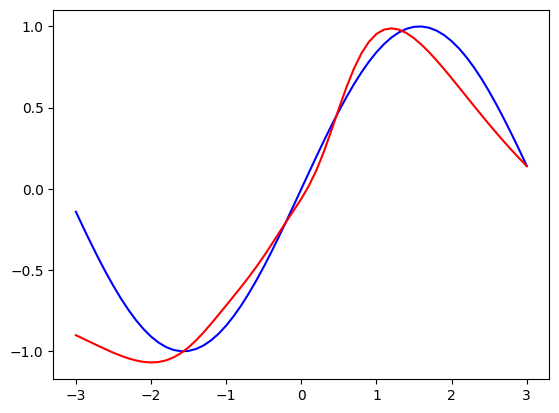

In [ ]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)


1/(50, error=1.3895364190839454
2/(50, error=1.2013037529783308
3/(50, error=1.0617738451656054
4/(50, error=0.9707211987942672
5/(50, error=0.8924455829452304
6/(50, error=0.8308561735919572
7/(50, error=0.7944966943539318
8/(50, error=0.7633049269516217
9/(50, error=0.741016022202883
10/(50, error=0.7157226853416835
11/(50, error=0.6783652696871292
12/(50, error=0.6394666091134097
13/(50, error=0.6152000425854909
14/(50, error=0.5986365220088655
15/(50, error=0.5863051772873539
16/(50, error=0.5765130869581814
17/(50, error=0.5682747511954053
18/(50, error=0.5610692967233001
19/(50, error=0.554630405316768
20/(50, error=0.5488371744879162
21/(50, error=0.5436131061751912
22/(50, error=0.5388787230389136
23/(50, error=0.5345386038515509
24/(50, error=0.5304967700553137
25/(50, error=0.5266806507414252
26/(50, error=0.523067496605814
27/(50, error=0.5196735203800469
28/(50, error=0.5165000761657037
29/(50, error=0.513522116216601
30/(50, error=0.510714118179862
31/(50, error=0.50805605

In [21]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [23]:
pip install simple-colors

In [24]:
import simple_colors

In [25]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 5 	true: 2
pred: 6 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 3 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 9 	true: 5
pred: 9 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 3 	true: 1
pred: 3 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.7
Correct: 14


In [26]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

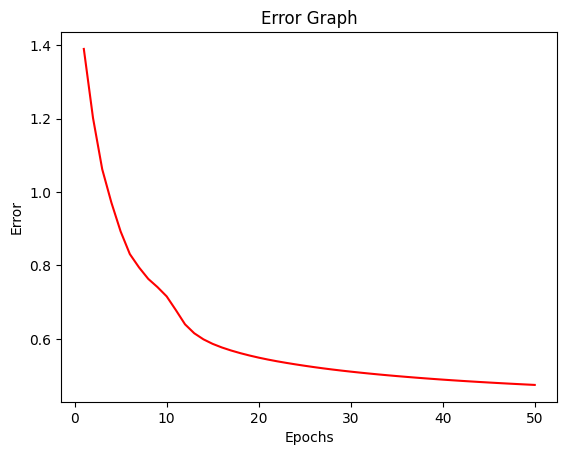

In [27]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()